# 回归分析
## 01 数据准备
机器学习算法要求数据具有某种格式，然后才能对数据进行算法训练。 我们对将要用于Sklearn库训练机器学习算法的数据，需要进行一些预处理的步骤。如把数据分为训练数据和测试数据，转化文本格式的数据为数值格式等。从上一节，我们可以使用pandas库从 CSV 文件中读取数据。 本节我们将采取另外一种方式，在Seaborn库中直接加载默认的数据集（本节内容要先安装seaborn库）。Seaborn库自带了一些数据集，要查看所有数据集目录，可以使用 get_dataset_names() 函数：

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.get_dataset_names()

使用load_dataset()函数加载指定的数据集，下面的代码加载了tips数据集并显示前5行：

In [4]:
tips_data = sns.load_dataset("tips")
print(tips_data.head())
print(tips_data.shape)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


该数据集一共有244条记录，每条记录共7项，记录了吃完饭后给小费的情况。7个数据项的含义依次是：账单总额、顾客给的小费额、性别、在吃饭时是否抽烟、吃饭的星期、时间（晚餐或日间餐）、聚餐人数。

接下来，我们需要把数据集分成“特征”和“标签”2部分。由于我们将根据数据建立模型，并且最终的目的是预测顾客吃完饭后会给多少钱的小费。因此，我们将小费这一列作为“标签”，而其他剩余的列则作为“特征”。下来将数据集分为2个：

In [5]:
X = tips_data.drop(['tip'], axis=1)
y = tips_data['tip']

在大多数情况下，机器学习算法只能处理数字。 因此，将分类数据（非数值类数据）转换为数字格式很重要。在数据中，首先将数值数据和非数值数据分开，然后将非数值的数据转换成数值类型后，再将他们合并起来。再tips数据集中，total_bill、tip和size都是数值型的，剩余的4列则不是。

In [6]:
X_numerical = X.drop(['sex', 'smoker', 'day', 'time'], axis=1)
X_categorical = X.filter(['sex', 'smoker', 'day', 'time'])

将有限个（可枚举）的非数值类值转换为数字的最常见方法之一是通过one-hot编码。 在one-hot编码中，对于原始列中的每个唯一值，都会创建一个新列。 例如，对于性别，会创建两列：女性和男性。 如果原始性别列包含男性，则在新创建的男性列中值为1，其他列的值为0。因此，对于每一个转换，其结果为只含有1个1，其他都为0的序列（这也是one-hot的名称来历）。但是，可以看到并不真正需要两列。只需要要1列，如女性列就足够了，因为当客户是女性时，可以设女性列中值为1，而值为0时，则表示为男性。因此，对于原始列中的所有N个值，我们需要N-1个one-hot编码列。pandas库的get_dummies()方法可以将列转换为one-hot编码。

In [7]:
X_categorical_convert = pd.get_dummies(X_categorical, drop_first=True)
X_categorical_convert.head()

,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,1,1,0,0,1,1
1,0,1,0,0,1,1
2,0,1,0,0,1,1
3,0,1,0,0,1,1
4,1,1,0,0,1,1


在tips数据集中，day的情形只有4种：Thur、Fri、Sat和Sun。所以day转换后只有3列。随后，我们将转换后的数值数据和原有的数值数据合并起来：

In [8]:
X = pd.concat([X_numerical, X_categorical_convert], axis=1)
X.head()

,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,2,1,1,0,0,1,1
1,10.34,3,0,1,0,0,1,1
2,21.01,3,0,1,0,0,1,1
3,23.68,2,0,1,0,0,1,1
4,24.59,4,1,1,0,0,1,1


再接下来，我们需要把数据分成2部分：一部分用于训练，一部分用于检测。我们将80%的数据用于训练，20%用于测试。
可以使用Sklearn库的train_test_split方法来完成：

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=0)

准备数据的最后一步（可选）是缩放数据（数据归一化）。 可以看到数据集的某些列包含较小的值，而其他列包含非常大的值。 最好将所有值转换为统一比例。 为此，可以使用 sklearn.preprocessing 模块中的 StandardScaler() 函数：

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

到此，我们已经准备好了数据。下面我们将使用不同的回归算法对数据进行分析、建模和预测。

## 02 线性回归

线性回归是一种线性模型，它假设输入和输出之间存在线性关系，并使用不同数据点之间的平均绝对误差等函数来最小化预测输出和实际输出之间的误差成本。
线性回归具有以下优点：

+ 线性回归是一种易于实现且易于解释的算法；
+ 即使庞大的数据集也只需要少量的训练时间；
+ 线性回归系数易于解释；线性回归算法的缺点。

线性回归算法的缺点：
+ 性能很容易受到异常值的影响；
+ 假设因变量和自变量之间存在线性关系，这可能导致误差增加。

使用Sklearn实现线性回归，可以使用sklearn.linear_model模块中的LinearRegression类。首先需要训练，使用LinearRegression类对象的fit()方法，将训练集X_train和X_test传递给fit()方法。训练完成后，可以使用类的predict()方法进行预测，此时传递给predict函数测试集数据。使用线性回归算法进行训练和预测的过程如下：

In [11]:
from sklearn.linear_model import LinearRegression
# 训练模型
lin_reg = LinearRegression()
regressor = lin_reg.fit(X_train, y_train)
# 使用测试集进行预测
y_pred_test = regressor.predict(X_test)
y_pred_train = regressor.predict(X_train)


Coefficients: 
 [ 0.78092503  0.19840546  0.00344838  0.01539503  0.13827768  0.1395068
  0.1833158  -0.20183948]
Intercept:
 2.9849230769230766
Variance score: 0.5545031052534933


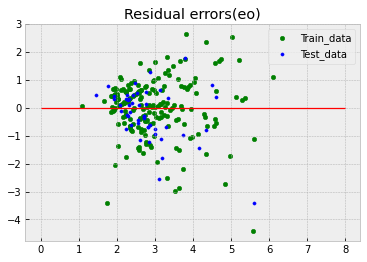

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

print('Coefficients: \n', regressor.coef_)
print('Intercept:\n', regressor.intercept_)
print('Variance score: {}'.format(regressor.score(X_test, y_test)))
plt.style.use('bmh')
plt.scatter(y_pred_train, y_pred_train - y_train, color="green", s=20, label='Train_data')
plt.scatter(y_pred_test, y_pred_test - y_test, color="blue", s=10, label='Test_data')
plt.hlines(y=0, xmin=0, xmax=8, color='red', linewidth=1.25)
plt.legend(loc='upper right')
plt.title("Residual errors(eo)")
plt.show()


上面输出的值依次是模型的系数（我们一共输入人8个变量，所以有8个系数），模型的截距，以及决定系数。
一旦训练了一个模型并对测试集进行了预测，进一步就是了解模型在对未知测试集进行预测方面的表现如何。常用的有平均绝对误差、均方误差和均方根误差。
平均绝对误差（Mean Absolute Error, MAE), MAE定义为预测值减去实际值的绝对误差的平均值，MAE的计算公式为：
$$
MAE = \displaystyle \frac {\sum_{i=1}^n |y_i-\hat{y}_i|} {n}
$$

均方误差 (Mean Squared Error，MSE) 类似于 MAE。 只是用平方取代了绝对值：
$$
MSE = \displaystyle \frac {\sum_{i=1}^n (y_i-\hat{y})^2}{n}
$$
MSE求平方根则是均方根误差（Root Mean Squared Error，RMSE）：
$$
RMSE = \sqrt{MSE}
$$
sklearn.metrics类可以计算这些指标，来对模型进行评价。预测值和实际值必须传递给这些方法：

In [13]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error: ', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

Mean Absolute Error: 0.7080218832979828
Mean Squared Error:  0.8939195221609608
Root Mean Squared Error: 0.9454731736865731


## 03其他的回归方法
### KNN回归
KNN(K-nearest neighbors)即k-最邻近。KNN是一种惰性学习算法，它基于寻找不同数据点之间的欧几里得距离。

In [14]:
from sklearn.neighbors import KNeighborsRegressor
KNN_reg = KNeighborsRegressor(n_neighbors=5)
regressor = KNN_reg.fit(X_train, y_train)
y_pred_test = regressor.predict(X_test)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

Mean Absolute Error: 0.7513877551020406
Mean Squared Error: 0.9462902040816326
Root Mean Squared Error: 0.9727744877830794


### 随机森林回归（Random Forest Regression）
随机森林是一种基于树的算法，将特征转换为树节点，然后使用熵损失进行预测。

In [15]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42, n_estimators=500)
regressor = rf_reg.fit(X_train, y_train)
y_pred_test = regressor.predict(X_test)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

Mean Absolute Error: 0.7045338775510206
Mean Squared Error: 0.8021385735673484
Root Mean Squared Error: 0.8956218920768677


## 04 K-Fold交叉验证
前面的例子里我们将数据分为80%的训练集和20%的测试集。这意味着只有20%的数据用于测试，而这20%的数据从未用于训练。为了获得更稳定的结果，建议数据集的所有数据至少使用一次进行训练和一次测试。可以使用K-Fold交叉验证技术来做到这一点。K次交叉验证，将数据分为K个部分。每次使用K-1部分的数据用于训练，第K部分数据用于测试。例如，当k=5时，数据被分成5个相等的部分，K1、K2、K3、K4 和 K5。在第一次迭代中，K1-K4 用于训练，而 K5 用于测试。在第二次，K1、K2、K3、K5 用于训练，K4 用于测试。如此进行5次。这样，每个部分至少使用一次测试和一次训练。可以使用sklearn中的cross_val_score()函数和model_selection模块执行交叉验证，如下所示：

In [16]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(regressor, X, y, cv=5, scoring='neg_mean_absolute_error'))

[-0.78752816 -0.59598449 -0.69340163 -0.99066    -0.89050833]


## 05对单一记录进行预测
我们将尝试使用随机森林回归算法预测第100条记录小费的值，并查看我们得到的输出。要注意的是必须先扩展单个记录，然后才能将其用作输入（此处会有1个警告，忽略即可）：

In [19]:
rf_reg = RandomForestRegressor(random_state=42, n_estimators=500)
regressor = rf_reg.fit(X_train, y_train)
single_record = sc.transform(X.values[100].reshape(1, -1))
predicted_tip = regressor.predict(single_record)
print(predicted_tip)

print(tips_data.loc[100]['tip'])

[2.26622]
2.5


c:\Users\cuish\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
